In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

In [3]:
# Load the dataset
file_path = '../../data/Data3.csv'  # Make sure the file is in the same directory as the code
data = pd.read_csv(file_path)

In [10]:
data.shape

(360303, 19)

In [5]:
# Select relevant columns
columns_to_normalize = ['AVG_NO_USER', 'AVG_USR_THRPUT_DL', 'DL_TRAFFIC_MB']
data = data[['EUTRANCELLFDD'] + columns_to_normalize]

In [6]:
# Normalize the data between 0-10
scaler = MinMaxScaler(feature_range=(0, 10))
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

In [7]:
# Group data by 'EUTRANCELLFDD'
grouped_data = data.groupby('EUTRANCELLFDD')

In [8]:
# Function to create LSTM model
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model

In [9]:
# To store MSE for each EUTRANCELLFDD
mse_results = {}

In [11]:
# Process each EUTRANCELLFDD
for cell, group in grouped_data:
    # Ensure there are enough samples to split
    if len(group) < 4:  # Minimum required for a 60-20-20 split
        continue
    
    # Prepare data
    X = group[['AVG_NO_USER', 'DL_TRAFFIC_MB']].values
    y = group['AVG_USR_THRPUT_DL'].values
    
    # Reshape X for LSTM [samples, time steps, features]
    X = X.reshape((X.shape[0], 1, X.shape[1]))
    
    # Split into train, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    # Create LSTM model
    model = create_lstm_model((X_train.shape[1], X_train.shape[2]))
    
    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    
    # Predict and calculate MSE
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    val_mse = mean_squared_error(y_val, model.predict(X_val))
    test_mse = mean_squared_error(y_test, model.predict(X_test))
    
    # Store MSE results
    mse_results[cell] = {'train_mse': train_mse, 'val_mse': val_mse, 'test_mse': test_mse}


3/3 [==============================] - 0s 2ms/step


7/7 [==============================] - 2s 3ms/step


1/1 [==============================] - 0s 20ms/step


1/1 [==============================] - 0s 12ms/step


2/2 [==============================] - 0s 8ms/step


...

1/1 [==============================] - 0s 35ms/step


1/1 [==============================] - 0s 34ms/step


7/7 [==============================] - 1s 2ms/step


1/1 [==============================] - 0s 47ms/step


3/3 [==============================] - 0s 499us/step


In [11]:
# Convert MSE results to DataFrame for easy sorting and analysis
mse_df = pd.DataFrame.from_dict(mse_results, orient='index')

# Display top 5 best and worst performing EUTRANCELLFDD based on test MSE
best_5 = mse_df.nsmallest(5, 'test_mse')
worst_5 = mse_df.nlargest(5, 'test_mse')


NameError: name 'mse_results' is not defined

In [14]:
print("Best 5 EUTRANCELLFDD based on Test MSE:")
print(best_5)

Best 5 EUTRANCELLFDD based on Test MSE:
             train_mse   val_mse  test_mse
CGANW23L21A   0.000000  0.000000  0.000000
CGANW23L21B   0.000000  0.000000  0.000000
CGANW23L21C   0.000000  0.000000  0.000000
CXUKH62LA     0.000009  0.000013  0.000006
CXUKH64LA     0.000010  0.000014  0.000007


In [15]:
print("\nWorst 5 EUTRANCELLFDD based on Test MSE:")
print(worst_5)


Worst 5 EUTRANCELLFDD based on Test MSE:
              train_mse    val_mse   test_mse
BMKSB05L26C3  30.404819  34.487097  32.930096
BMKSB05L26C2  28.960195  29.330985  31.061364
BMBNC21L26C2  21.704462  19.684846  28.245818
BMKSB05L26C1  24.692987  26.951435  26.818630
CXUKH08L26C3  21.370262  16.301859  26.275135


In [16]:
import matplotlib.pyplot as plt

# Function to plot actual vs predicted values
def plot_actual_vs_predicted(cell, y_true, y_pred, title):
    plt.figure(figsize=(10, 6))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'{title} - {cell}')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

1/1 [==============================] - 2s 2s/step


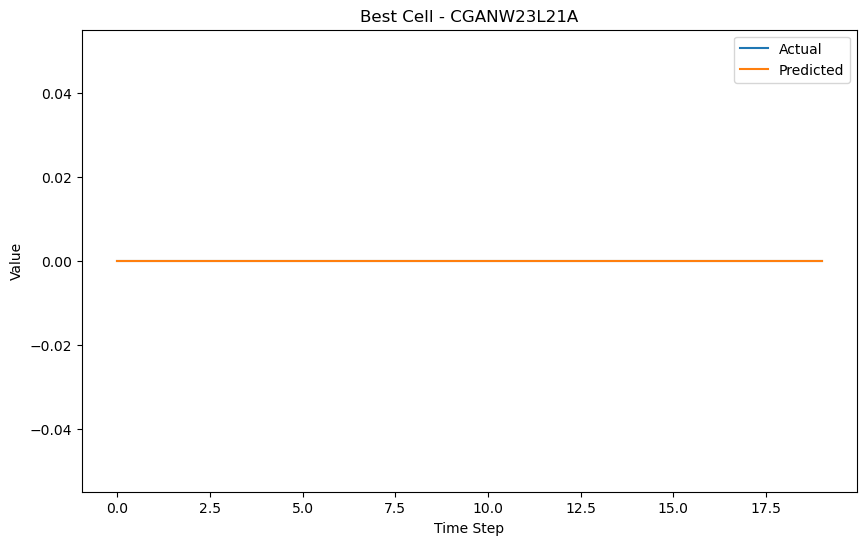

1/1 [==============================] - 1s 1s/step


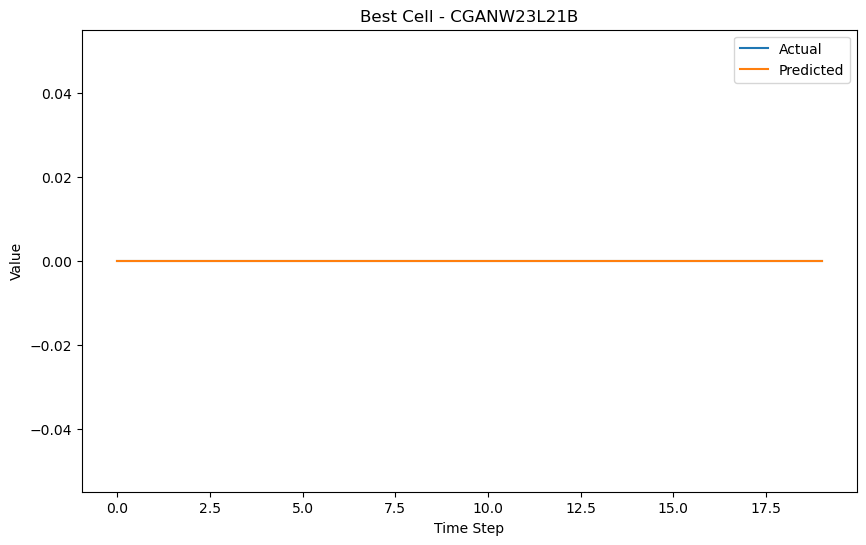

1/1 [==============================] - 2s 2s/step


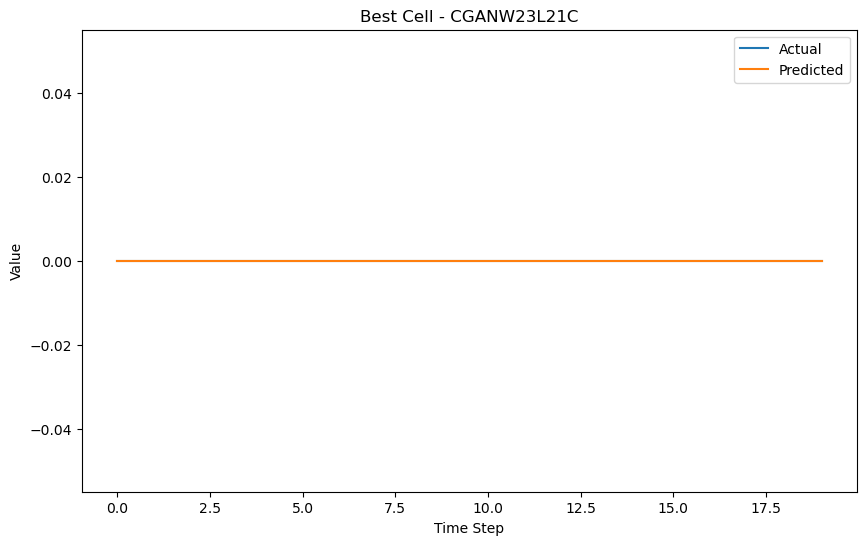

3/3 [==============================] - 2s 3ms/step


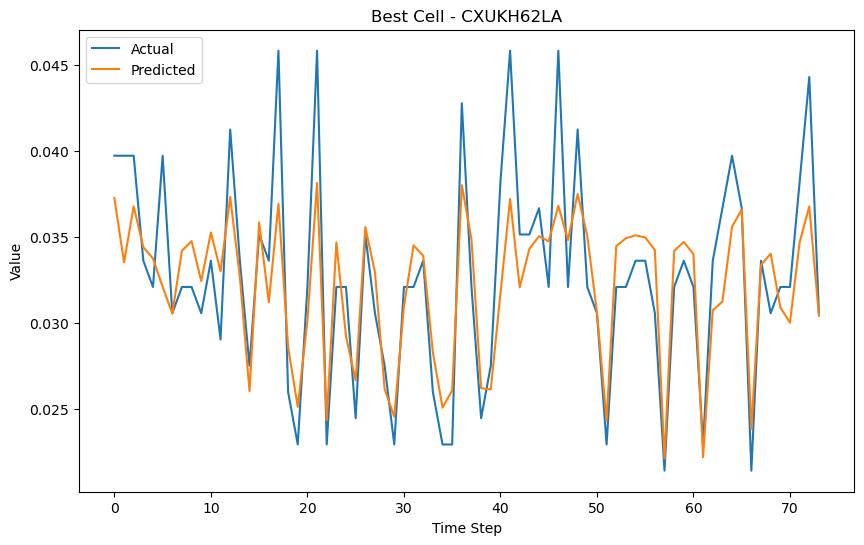

3/3 [==============================] - 1s 2ms/step


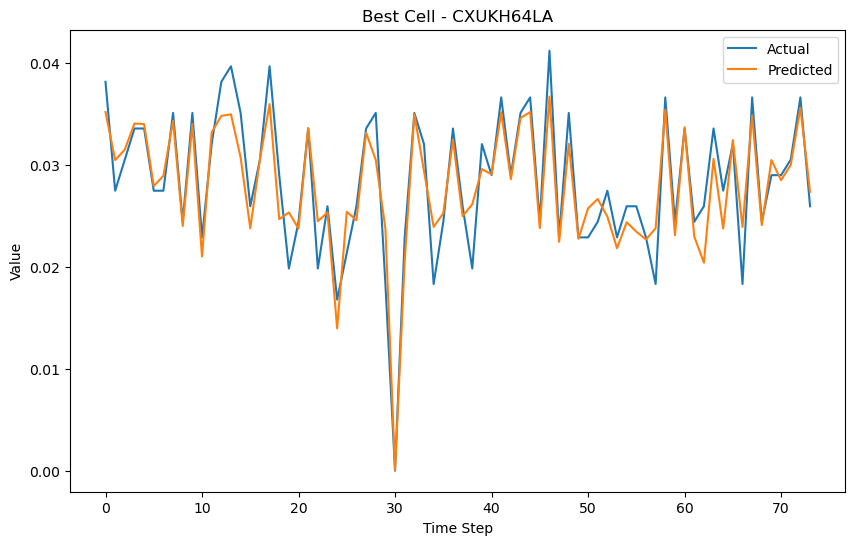

1/1 [==============================] - 1s 1s/step


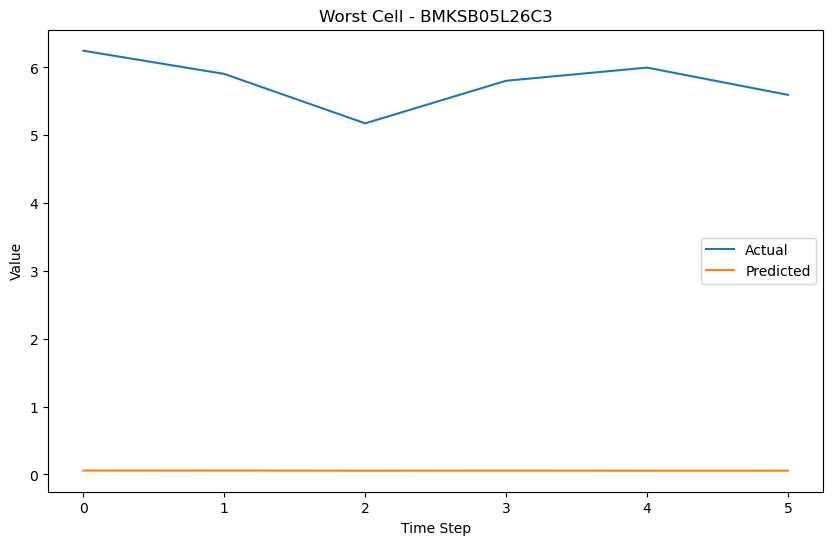

1/1 [==============================] - 1s 1s/step


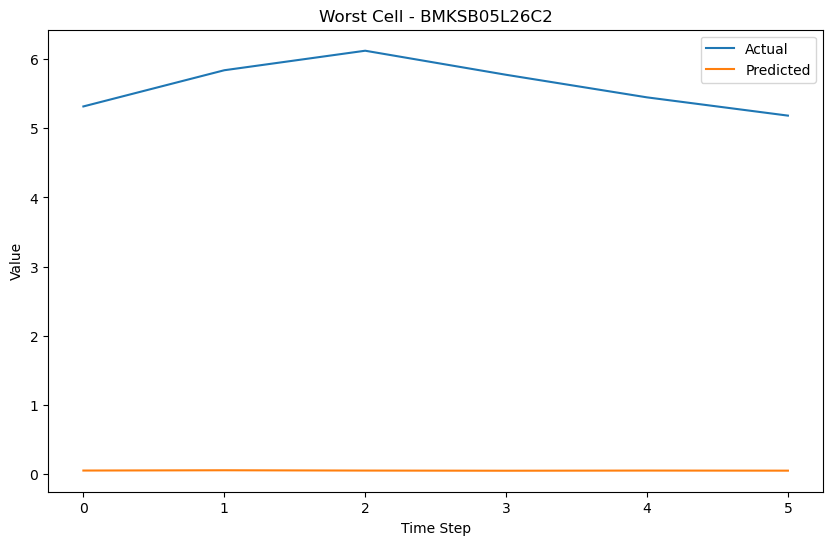

1/1 [==============================] - 2s 2s/step


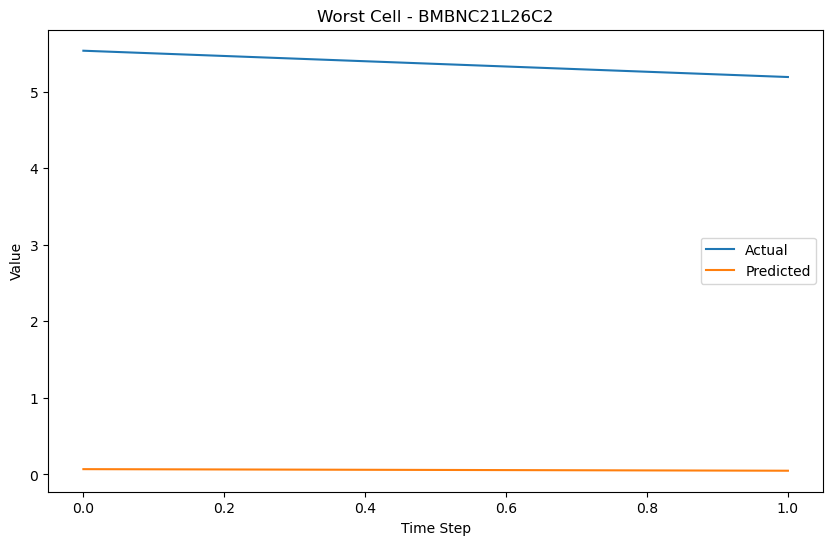

1/1 [==============================] - 1s 1s/step


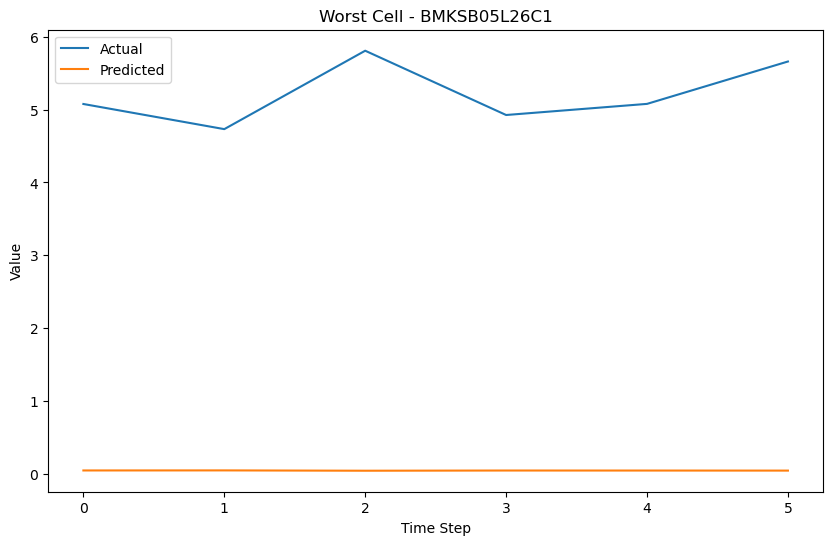

1/1 [==============================] - 2s 2s/step


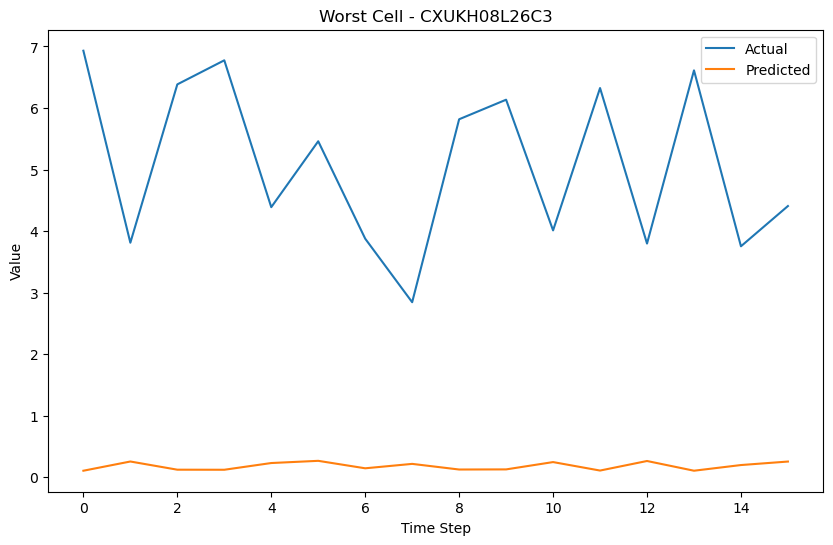

In [17]:

# Plot for best and worst 5 cells
for cell in best_5.index:
    group = grouped_data.get_group(cell)
    
    # Prepare data
    X = group[['AVG_NO_USER', 'DL_TRAFFIC_MB']].values
    y = group['AVG_USR_THRPUT_DL'].values
    
    # Reshape X for LSTM [samples, time steps, features]
    X = X.reshape((X.shape[0], 1, X.shape[1]))
    
    # Split into train, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    # Create and train the model
    model = create_lstm_model((X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Plot actual vs predicted
    plot_actual_vs_predicted(cell, y_test, y_pred, 'Best Cell')

for cell in worst_5.index:
    group = grouped_data.get_group(cell)
    
    # Prepare data
    X = group[['AVG_NO_USER', 'DL_TRAFFIC_MB']].values
    y = group['AVG_USR_THRPUT_DL'].values
    
    # Reshape X for LSTM [samples, time steps, features]
    X = X.reshape((X.shape[0], 1, X.shape[1]))
    
    # Split into train, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    # Create and train the model
    model = create_lstm_model((X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Plot actual vs predicted
    plot_actual_vs_predicted(cell, y_test, y_pred, 'Worst Cell')

In [19]:
import pandas as pd

# Modify the loop to store predictions
prediction_results = []

for cell, group in grouped_data:
    # Ensure there are enough samples to split
    if len(group) < 4:
        continue
    
    # Prepare data
    X = group[['AVG_NO_USER', 'DL_TRAFFIC_MB']].values
    y = group['AVG_USR_THRPUT_DL'].values
    
    # Reshape X for LSTM [samples, time steps, features]
    X = X.reshape((X.shape[0], 1, X.shape[1]))
    
    # Split into train, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    # Create and train the model
    model = create_lstm_model((X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Store the results
    prediction_results.append(pd.DataFrame({
        'EUTRANCELLFDD': cell,
        'Actual': y_test.flatten(),
        'Predicted': y_pred.flatten()
    }))

3/3 [==============================] - 2s 8ms/step


3/3 [==============================] - 1s 0s/step


3/3 [==============================] - 1s 8ms/step


3/3 [==============================] - 1s 0s/step


3/3 [==============================] - 1s 0s/step


In [20]:
# Combine all predictions into a single DataFrame
predictions_df = pd.concat(prediction_results)

# Calculate the percentage change of predicted AVG_USR_THRPUT_DL for each EUTRANCELLFDD
predictions_df['PCT_CHANGE'] = predictions_df.groupby('EUTRANCELLFDD')['Predicted'].pct_change() * 100

# Define conditions for degradation and increase
degraded_condition = predictions_df['PCT_CHANGE'] <= -50
increased_condition = predictions_df['PCT_CHANGE'] >= 0.1

# Count the number of cells that meet each condition
degraded_cells_count = predictions_df[degraded_condition].groupby('EUTRANCELLFDD').ngroups
increased_cells_count = predictions_df[increased_condition].groupby('EUTRANCELLFDD').ngroups

print(f"Number of cells where predicted AVG_USR_THRPUT_DL degraded by 50% or more: {degraded_cells_count}")
print(f"Number of cells where predicted AVG_USR_THRPUT_DL increased by at least 0.1%: {increased_cells_count}")

Number of cells where predicted AVG_USR_THRPUT_DL degraded by 50% or more: 378
Number of cells where predicted AVG_USR_THRPUT_DL increased by at least 0.1%: 1455
